In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model

from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, LayerNormalization, GlobalAveragePooling1D

from tensorflow.keras.layers import MultiHeadAttention

from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Bloque de self-attention desde 0
# Crear una frase de ejemplo

frase="el perro cruzo la calle porque estaba cansado"

palabras = frase.split()

print("Palabras de la frase:")
print(palabras)

num_tokens = len(palabras)

print("Cantidad de palabras de la frase:", num_tokens)

# Creacion de embeddings ficticios
embeddin_dim = 4
# Creacion de una matriz con numeros aleatorios entre 0 y 1
X= np.random.randn(num_tokens, embeddin_dim)

print("Matriz de embeddings:")
print(X)
print(X.shape)

Palabras de la frase:
['el', 'perro', 'cruzo', 'la', 'calle', 'porque', 'estaba', 'cansado']
Cantidad de palabras de la frase: 8
Matriz de embeddings:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763   0.0675282  -1.42474819]
 [-0.54438272  0.11092259 -1.15099358  0.37569802]
 [-0.60063869 -0.29169375 -0.60170661  1.85227818]]
(8, 4)


In [3]:
# Crearemos las matrices W_Q, W_K y W_V

d_k=4

# Matriz W_Q esta matriz transforma cada embedding original en una Query
W_Q= np.random.rand(embeddin_dim, d_k)

# Matriz W_K esta matriz transforma cada embedding original en  una Key
# Aunque tiene la misma forma que  W_Q sus valores son distintos
W_K= np.random.rand(embeddin_dim, d_k)

# Matriz W_V esta matriz transforma cada embedding original en un Value
# V contiene la informacion que sera mezclada al final usando los pesos de atencion
W_V= np.random.rand(embeddin_dim, d_k)

# Cada fila de Q es la "pregunta que hace una palabra"
# Forma de Q: (num_tokens, d_k)
Q= X @ W_Q

# Cada fila de K funciona como una "etiqueta" o "indice"
# Contra la cual se compararán las Queries
K= X @ W_K

# Cada fila de V contiene la informacion que podria ser recuperada
# si una palabra recibe atencion
V= X @ W_V

In [4]:
# Calculamos los scores de QK^T

scores= Q @ K.T
print("Scores crudos QK^T:")
print(scores)

# Ecalamiento de los scores
factor_de_escala= np.sqrt(d_k)

# En el escalamiento reducimos la magnitud de los scores antes de aplicar softmax
scores_escalados= scores/factor_de_escala

print("Scores escalados:")
print(scores_escalados)

Scores crudos QK^T:
[[  7.56469386   6.97071585  -2.02845432 -13.67794942  -8.18903604
   -3.40383782  -3.04361839   2.46021628]
 [  5.51772135   4.82381339  -1.1271558  -10.90731339  -5.78036462
   -2.92246809  -1.88514882   2.02202232]
 [ -2.44009554  -2.32809285   0.63679933   4.74956799   2.67179054
    0.99706046   1.11483723  -0.60219306]
 [ -9.83437304  -8.61705102   2.38839041  17.65468961  10.40736488
    5.04601674   3.3199333   -3.89396968]
 [ -8.37060333  -7.8174075    2.2876407   15.25855386   9.1186836
    3.60776101   3.53126262  -2.52685443]
 [ -2.64171778  -2.04243278   0.46149107   4.73393025   2.62533682
    1.80748341   0.46932476  -1.51126898]
 [ -2.1765544   -2.00452235   0.45959516   4.57030064   2.33305144
    0.99352081   0.91700748  -0.56833487]
 [  3.37397407   3.01609055  -0.91541164  -5.71778674  -3.60529686
   -1.6730186   -1.1833356    1.34692905]]
Scores escalados:
[[ 3.78234693  3.48535792 -1.01422716 -6.83897471 -4.09451802 -1.70191891
  -1.5218092   1

In [5]:
# Definir softmax

def softmax(matriz):
  # Restamos el maximo de cada fila
  # Sin esta, el exp podria producir numeros demaciado grandes
  matriz_estable= matriz - np.max(matriz, axis=1, keepdims=True)

  # Aplicamos la exp a cada elemento
  exp_matriz= np.exp(matriz_estable)

  # Sumamos los valores previamente calculados por fila
  suma_exp = np.sum(exp_matriz, axis=1, keepdims=True)

  # Dividimos cada exponente entre la suma total de su fila
  # Esto normaliza la fila
  return exp_matriz/suma_exp

pesos_atencion = softmax(scores_escalados)

print("Pesos de atencion:")
print(pesos_atencion)

print("Suma de pesos por fila:")
print(np.sum(pesos_atencion, axis=1))

Pesos de atencion:
[[5.43849644e-01 4.04108662e-01 4.49110479e-03 1.32647011e-05
  2.06347810e-04 2.25783632e-03 2.70341743e-03 4.23697229e-02]
 [5.10144706e-01 3.60589591e-01 1.83982555e-02 1.38370149e-04
  1.79616070e-03 7.49772548e-03 1.25944890e-02 8.88407027e-02]
 [1.42844746e-02 1.51072476e-02 6.65278521e-02 5.20091636e-01
  1.84033222e-01 7.96586996e-02 8.44905455e-02 3.58063228e-02]
 [1.04250016e-06 1.91608270e-06 4.70127321e-04 9.71069339e-01
  2.59127600e-02 1.77546337e-03 7.49026976e-04 2.03244280e-05]
 [7.01771419e-06 9.25381103e-06 1.44745131e-03 9.48859627e-01
  4.40500169e-02 2.80068617e-03 2.69558500e-03 1.30361584e-04]
 [1.30384564e-02 1.75937843e-02 6.15289379e-02 5.20988094e-01
  1.81531733e-01 1.20602953e-01 6.17704100e-02 2.29456317e-02]
 [1.77467536e-02 1.93408344e-02 6.63058009e-02 5.17821260e-01
  1.69187154e-01 8.65948384e-02 8.33445774e-02 3.96587805e-02]
 [3.93713132e-01 3.29205045e-01 4.61053824e-02 4.17762184e-03
  1.20129722e-02 3.15674402e-02 4.03248425e-

In [6]:
# Calculamos el contexto

# Multiplicamos los pesos de atencion por V
# Cada fila es la nueva representacion contextualizada de una palabra
contexto = pesos_atencion @ V

print("Vectores contextualizados:")
print(contexto)

Vectores contextualizados:
[[ 1.06737749  1.10105053  1.24331512  0.92212175]
 [ 0.95181669  0.97943341  1.1643577   0.87791614]
 [-1.90448621 -1.01679005 -1.16084413 -0.57086501]
 [-3.07436763 -1.21472111 -1.50340627 -0.54177167]
 [-3.0247996  -1.22318191 -1.50673966 -0.56126726]
 [-1.90412025 -0.95036125 -1.15444318 -0.56288753]
 [-1.87703812 -0.97258886 -1.11694514 -0.53476418]
 [ 0.72824366  0.72566455  0.92516088  0.70521733]]


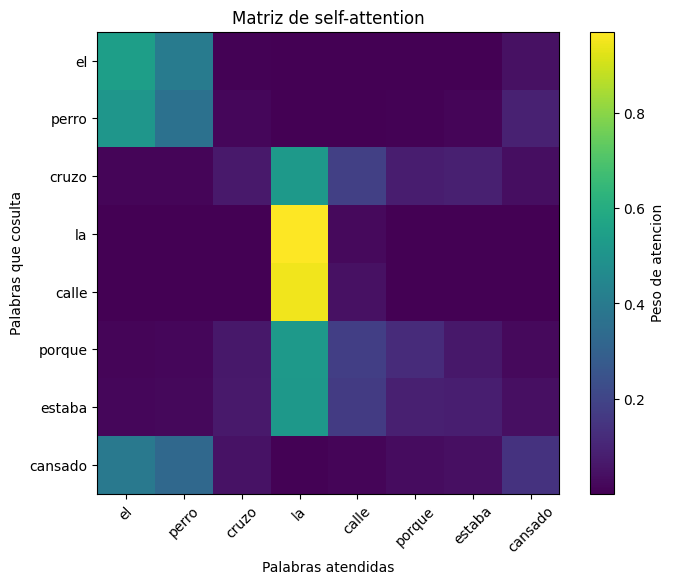

In [7]:
# Visualizamos los pesos de atencion

plt.figure(figsize=(8,6))

plt.imshow(pesos_atencion, cmap="viridis")

plt.colorbar(label="Peso de atencion")
plt.xticks(range(num_tokens), palabras, rotation=45)
plt.yticks(range(num_tokens), palabras)
plt.title("Matriz de self-attention")
plt.xlabel("Palabras atendidas")
plt.ylabel("Palabras que cosulta")
plt.show()

In [8]:
# Bloque B

# Mini encoder para tranformes para clasificacion
# Vamos a crear dataset sintetico

frases = [
    # Frases positivas.
    "la clase fue excelente y clara",
    "el curso fue util y ordenado",
    "la explicacion fue precisa y brillante",
    "la practica fue interesante y completa",
    "el modelo funciono correctamente",
    "la sesion fue muy buena",
    "el ejemplo fue claro y util",
    "la actividad fue excelente",
    "el resultado fue estable y correcto",
    "la explicacion fue ordenada",

    # Frases negativas.
    "la clase fue confusa y pesada",
    "el curso fue aburrido y malo",
    "la explicacion fue pobre y desordenada",
    "la practica fue terrible",
    "el modelo fallo constantemente",
    "la sesion fue muy mala",
    "el ejemplo fue confuso",
    "la actividad fue deficiente",
    "el resultado fue inestable e incorrecto",
    "la explicacion fue desordenada"
]

etiquetas = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

df= pd.DataFrame({
    "frase": frases,
    "etiqueta": etiquetas
})

print(df)

                                      frase  etiqueta
0            la clase fue excelente y clara         1
1              el curso fue util y ordenado         1
2    la explicacion fue precisa y brillante         1
3    la practica fue interesante y completa         1
4          el modelo funciono correctamente         1
5                   la sesion fue muy buena         1
6               el ejemplo fue claro y util         1
7                la actividad fue excelente         1
8       el resultado fue estable y correcto         1
9               la explicacion fue ordenada         1
10            la clase fue confusa y pesada         0
11             el curso fue aburrido y malo         0
12   la explicacion fue pobre y desordenada         0
13                 la practica fue terrible         0
14           el modelo fallo constantemente         0
15                   la sesion fue muy mala         0
16                   el ejemplo fue confuso         0
17              la actividad

In [9]:
# Tokenizamos y padeamos

X_texto = df["frase"].tolist()
y = df["etiqueta"].tolist()

X_train_texto, X_test_texto, y_train, y_test = train_test_split(X_texto, y,
                                                                test_size=0.25,
                                                                random_state=42,
                                                                stratify=y)
tokenizer = Tokenizer(oov_token="<OOV>")

tokenizer.fit_on_texts(X_train_texto)

word_index = tokenizer.word_index

vocab_size = len(word_index) + 1

X_train_seq = tokenizer.texts_to_sequences(X_train_texto)

X_test_seq = tokenizer.texts_to_sequences(X_test_texto)

max_len = max(len(seq) for seq in X_train_seq)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
)

y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

# Recorremos el diccionario palabra con indice
for i, (palabra, indice) in enumerate(word_index.items()):
  if i >= 15:
    break
  print(f"{palabra}: {indice}")
#

<OOV>: 1
fue: 2
la: 3
y: 4
el: 5
explicacion: 6
clase: 7
sesion: 8
muy: 9
curso: 10
util: 11
ejemplo: 12
resultado: 13
desordenada: 14
excelente: 15


In [10]:
# Funcion de pocisionamiento del encoding

def crear_positional_ecoding(longitud_secuencia, dimension_modelo):

  # Creamos una matriz de ceros
  positional_encoding= np.zeros((longitud_secuencia, dimension_modelo))

  for pos in range(longitud_secuencia):
    for i in range(dimension_modelo):

      denominador = np.power(
          10000,
          (2*(i//2))/dimension_modelo
      )

      # Si la dimension es par usamos seno
      # PE(pos,2i)=sin(pos/10000^(2i/d_model))
      if i % 2 == 0:
        positional_encoding[pos,i]= np.sin(pos/denominador)
      else:
        # Si la dimension es impar usamos coseno
        positional_encoding[pos,i]= np.cos(pos/denominador)

  # Agregamos una dimension extra al inicio.
  # Esta dimension extra representa el batch
  # Asi se puede sumar facilmente a los embeddings de keras
  positional_encoding = positional_encoding[np.newaxis, ...]

  # Convertimos la matriz numpy a tensor de TF
  return tf.cast(positional_encoding, dtype=tf.float32)

In [11]:
# Capa personalizada del positional encoding

# Clase personalizada
class PositionalEncodingLayer(tf.keras.layers.Layer):

  # Constructor de la capa
  def __init__ (self, max_len, dimension_modelo):
    super(PositionalEncodingLayer, self).__init__()

    self.max_len = max_len

    self.dimension_modelo = dimension_modelo

    self.positional_econding = crear_positional_ecoding(
        max_len,
        dimension_modelo
    )

  def call(self, x):

    longitud_actual= tf.shape(x)[1]

    pe_recortado = self.positional_econding[:, :longitud_actual, :]

    return x + pe_recortado

In [12]:
# Bloque del encoder del traformer

def transformer_encoder_bloque(x, num_head, key_dim, ff_dim, dropout_rate=0.1):
  attention_output = MultiHeadAttention(
      num_heads=num_head,
      key_dim=key_dim
  )(x,x)

  attention_output= Dropout(dropout_rate)(attention_output)

  x = x+ attention_output

  x = LayerNormalization(epsilon=1e-6)(x)

  # Primera capa de lfeedfoward Network
  # Expande la representacion a una dimension mayor ff_dim
  ffn_output= Dense(ff_dim, activation="relu")(x)

  # Segunda capa del FFN
  # Regresamos la representacion a la dimension original
  ffn_output= Dense(
      x.shape[-1]
  )(ffn_output)

  ffn_output= Dropout(dropout_rate)(ffn_output)

  x = x + ffn_output

  x= LayerNormalization(epsilon=1e-6)(x)

  return x

In [13]:
# Construimos el modelo tranformer

dimension_modelo = 32

num_heads = 2

key_dim=16

ffn_dim=64

input_layer = Input(shape=(max_len,),
                    name="entrada_tokens")
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=dimension_modelo,
    name="embedding_tokens"
)(input_layer)

# Sumammos el positional encoding a los embeddings
x= PositionalEncodingLayer(
    max_len=max_len,
    dimension_modelo=dimension_modelo
)(embedding_layer)

# Aplicamos bloque encoder para transformer
x= transformer_encoder_bloque(
    x=x,
    num_head=num_heads,
    key_dim=key_dim,
    ff_dim=ffn_dim,
    dropout_rate=0.1
)

x = GlobalAveragePooling1D()(x)

x =Dense(32,
         activation="relu")(x)

x= Dropout(0.2)(x)
output_layer = Dense (
    1,
    activation="sigmoid"
)(x)

modelo_transformer= Model(
    inputs=input_layer,
    outputs=output_layer,
    name="mini_tranformer"
)

modelo_transformer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_transformer.summary()

Model: "mini_tranformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_tokens      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_tokens    │ (None, 6, 32)     │      1,216 │ entrada_tokens[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 6, 32)     │          0 │ embedding_tokens… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 32)     │      4,224 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 32)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 6, 32)     │          0 │ positional_encod… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 6, 32)     │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 64)     │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6, 32)     │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 6, 32)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 6, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 32)     │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,849 (42.38 KB)

 Trainable params: 10,849 (42.38 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Entrenamos el mini transformer

historial= modelo_transformer.fit(
    X_train_pad,
    y_train_np,
    epochs=50,
    batch_size=4,
    validation_split=0.2,
    verbose=0
)

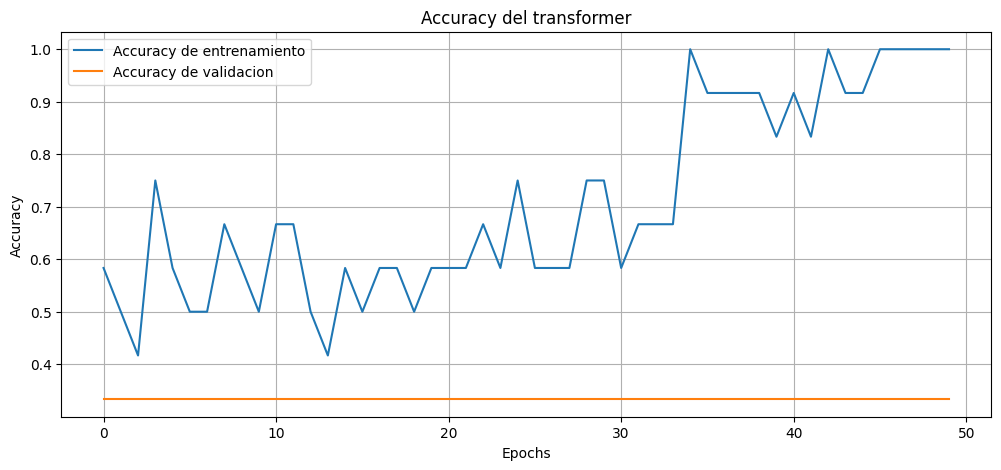

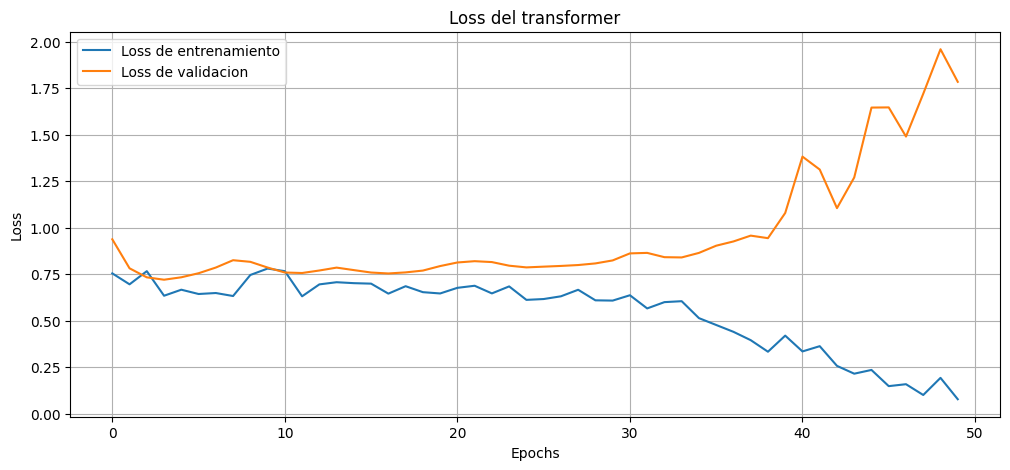

In [17]:
#Graficas de entrenamiento

plt.figure(figsize=(12,5))
plt.plot(historial.history["accuracy"], label="Accuracy de entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Accuracy de validacion")

plt.title("Accuracy del transformer")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(historial.history["loss"], label="Loss de entrenamiento")
plt.plot(historial.history["val_loss"], label="Loss de validacion")

plt.title("Loss del transformer")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Probamos frases nuevas

frases_nuevas=[
    "la clase fue excelente",
    "la explicacion fue confusa",
    "el modelo funciono correctamente",
    "la practica fue terrible",
    "el resultado fue estable y correcto"]

seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)

pad_nuevas = pad_sequences(
    seq_nuevas,
    maxlen=max_len,
    padding="post"
)

predicciones = modelo_transformer.predict(pad_nuevas, verbose=0)

for i, frase in enumerate(frases_nuevas):
  print("Frase:", frase)

  print(f"Probabilidad positiva: {predicciones[i][0]:.4f}")

  if predicciones[i][0] >= 0.6:
    print("Clasificacion: positiva")
  elif predicciones[i][0] < 0.6 and predicciones[i][0]>0.5:
    print("El modelo esta dudando")
  else:
    print("Clasificacion: negativa")
  print("-"*70)

Frase: la clase fue excelente
Probabilidad positiva: 0.7150
Clasificacion: positiva
----------------------------------------------------------------------
Frase: la explicacion fue confusa
Probabilidad positiva: 0.4130
Clasificacion: negativa
----------------------------------------------------------------------
Frase: el modelo funciono correctamente
Probabilidad positiva: 0.1125
Clasificacion: negativa
----------------------------------------------------------------------
Frase: la practica fue terrible
Probabilidad positiva: 0.4843
Clasificacion: negativa
----------------------------------------------------------------------
Frase: el resultado fue estable y correcto
Probabilidad positiva: 0.8112
Clasificacion: positiva
----------------------------------------------------------------------
